In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import numpy as np
import os
import sys
from pathlib import Path
from tqdm import tqdm
import pandas as pd 
from scipy.stats import boxcox, pearsonr
import matplotlib.pyplot as plt
from string import ascii_lowercase
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib import colorbar, colors, gridspec
from matplotlib.cm import ScalarMappable
from string import ascii_lowercase
import seaborn as sns

HOME = Path(os.getcwd()).parents[0]


sys.path.insert(1, str(HOME))

from src.scoring import get_convoluted_fractions, calculate_fss, calculate_fractions_SSIM

latitude_range = np.arange(-11.95, 15.95, 0.1)
longitude_range = np.arange(25.05, 49.05, 0.1)

plt.rcParams.update({'font.size': 12})

In [3]:
def fss_from_biases(mu_bias, sigma_bias, corr, C):
    
    numerator = 2*( mu_bias + sigma_bias* (C**2) *corr )
    denominator = 1 + mu_bias**2 + (1 + sigma_bias**2) * C**2
    
    return numerator / denominator

def bdnss_from_biases(mu_bias, sigma_bias, corr, C):
    
    return (2*corr*sigma_bias - sigma_bias**2) - (1/C**2)*( 1 - mu_bias)**2 

def fss_bsigma_max(C, corr):
    
    denominator = C**2 * corr
    
    numerator = np.sqrt(1 + 2*C**2*corr**2 + C**4 * corr**2) - 1
    
    return numerator / denominator

def fss_bmu_max(C, corr, B_sigma):
    
    term1 = np.sqrt(1 + (1 + B_sigma**2) * C**2 +  B_sigma**2 * C**4 * corr**2 )
    term2 = B_sigma * C**2 * corr
    
    return term1 - term2


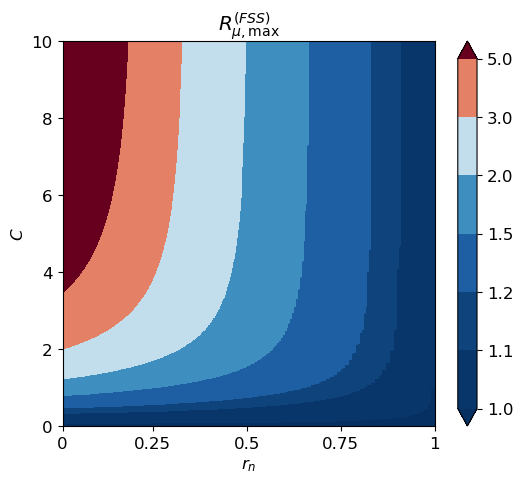

In [4]:
import matplotlib as mpl


C_vals = np.linspace(0.001,10,1000
                )
corr_vals = np.linspace(0,1,100)
b_sigma = 1

results_arr = np.empty(shape=(len(C_vals), len(corr_vals)))
results_minus_corr = np.empty(shape=(len(C_vals), len(corr_vals)))

for ii, C in enumerate(C_vals):
        for jj, corr in enumerate(corr_vals):
            
            results_arr[ii,jj] = fss_bmu_max(C=C, corr=corr, B_sigma=b_sigma)
            # results_minus_corr[ii,jj] = np.max([0,fss_bmu_max(C, corr)]) - np.max([0.0, corr])

fig, ax = plt.subplots(1,1, figsize=(6,5))

level_gap = 0.1
im= ax.contourf(np.round(results_arr,2), 
                levels=[1,1.1,1.2, 1.5,2,3,5], 
                cmap='RdBu_r', extend='both')
cbar = plt.colorbar(im)
ax.set_title('$R_{\mu, \max}^{ ({FSS})}$')


ax.set_xticks([0, 24, 49, 74, 99])
ax.set_xticklabels([0,0.25,0.5,0.75,1])
ax.set_xlabel('$r_n$')

ytick_label_locs = [1, 200, 400, 600, 800, 1000]
ax.set_yticks(ytick_label_locs)
ax.set_yticklabels([0, 2,4,6,8,10])
ax.set_ylabel('$C$')

plt.savefig(f'bmu_max_comparison.pdf', format='pdf', bbox_inches='tight')


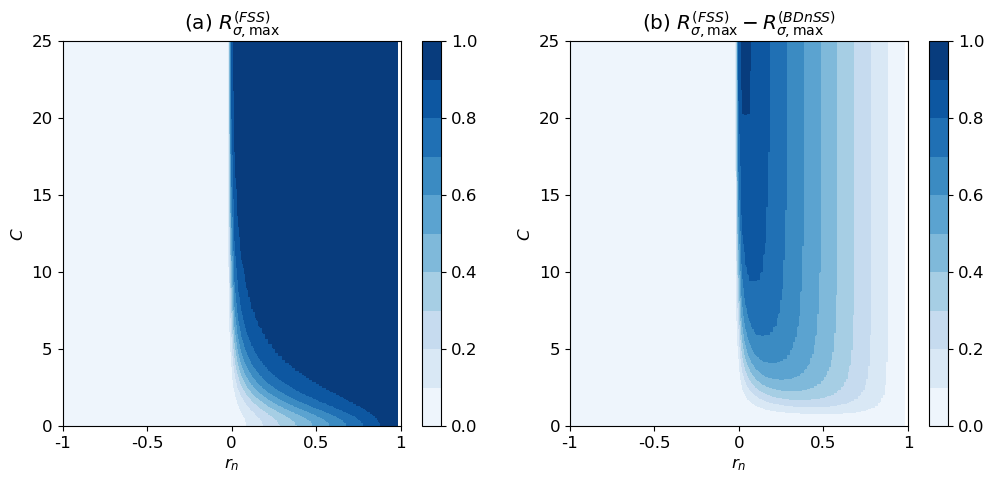

In [6]:
import matplotlib as mpl


gamma_vals = np.linspace(0.001,25,1000
                )
corr_vals = np.linspace(-1,1,100)

results_arr = np.empty(shape=(len(gamma_vals), len(corr_vals)))
results_minus_corr = np.empty(shape=(len(gamma_vals), len(corr_vals)))

for ii, gamma in enumerate(gamma_vals):
        for jj, corr in enumerate(corr_vals):
            
            results_arr[ii,jj] = np.max([0,fss_bsigma_max(gamma, corr)]) 
            results_minus_corr[ii,jj] = np.max([0,fss_bsigma_max(gamma, corr)]) - np.max([0.0, corr])
            
            if np.isnan(results_arr[ii,jj]):
                print(gamma, corr)

fig, axs = plt.subplots(1,2, figsize=(2*6,5))

level_gap = 0.1
im= axs[0].contourf(np.round(results_arr,2), levels=np.arange(0,1+level_gap,level_gap), cmap='Blues')
cbar = plt.colorbar(im)
axs[0].set_title('(a) $R_{\sigma, \max}^{ ({FSS})}$')

im2= axs[1].contourf(np.round(results_minus_corr,2), levels=np.arange(0,1+level_gap,level_gap), cmap='Blues')
cbar = plt.colorbar(im2)
axs[1].set_title('(b) $R_{\sigma, \max}^{(FSS)} - R_{\sigma, \max}^{(BDnSS)}$')

for ax in axs:
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xticklabels([-1, -0.5, 0, 0.5, 1])
    ax.set_xlabel('$r_n$')

    ytick_label_locs = [1, 200, 400, 600, 800, 1000]
    ax.set_yticks(ytick_label_locs)
    ax.set_yticklabels([0, 5,10,15,20,25])
    ax.set_ylabel('$C$')

plt.savefig(f'bsigma_max_comparison.pdf', format='pdf', bbox_inches='tight')
